# Colab Session: tumor-seg
Generated from colab-cli history log.

**Session Created**: 2026-08-13 13:30:35
- Endpoint: `gpu-t4-s-kkb-usw1b2-1gmzci3rr43l2`
- Hardware: `T4`

*File Operation*: `upload` on `/content/kaggle.json`

In [ ]:
import os
import shutil
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K


In [ ]:
# Setup ~/.kaggle directory
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)
target_path = os.path.join(kaggle_dir, "kaggle.json")

# 1. Check if environment variables are set
if "KAGGLE_USERNAME" in os.environ and "KAGGLE_KEY" in os.environ:
    with open(target_path, "w") as f:
        json.dump({"username": os.environ["KAGGLE_USERNAME"], "key": os.environ["KAGGLE_KEY"]}, f)
    print("Created ~/.kaggle/kaggle.json from environment variables.")
# 2. Check if kaggle.json exists in working directory or /content/
elif os.path.exists("kaggle.json"):
    shutil.copy("kaggle.json", target_path)
    print("Found kaggle.json in working directory and copied to ~/.kaggle/kaggle.json.")
elif os.path.exists("/content/kaggle.json"):
    shutil.copy("/content/kaggle.json", target_path)
    print("Found /content/kaggle.json and copied to ~/.kaggle/kaggle.json.")
else:
    print("Warning: kaggle.json not found in environment variables or working directory.")

# Set required permissions
if os.path.exists(target_path):
    os.chmod(target_path, 0o600)
    print("Permissions 600 set for ~/.kaggle/kaggle.json")


Found kaggle.json in working directory and copied to ~/.kaggle/kaggle.json.
Permissions 600 set for ~/.kaggle/kaggle.json


In [ ]:
!ls -l ~/.kaggle/kaggle.json


-rw------- 1 root root 72 Aug 13 13:30 /root/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -q -o lgg-mri-segmentation.zip


Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0


  2% 14.0M/714M [00:00<00:10, 69.0MB/s]

  5% 33.0M/714M [00:00<00:05, 125MB/s] 

 13% 93.0M/714M [00:00<00:04, 156MB/s]

 19% 134M/714M [00:00<00:03, 186MB/s]

...

 68% 489M/714M [00:03<00:01, 216MB/s]

 76% 541M/714M [00:03<00:00, 226MB/s]

 83% 592M/714M [00:03<00:00, 245MB/s]

 94% 669M/714M [00:04<00:00, 252MB/s]

100% 714M/714M [00:04<00:00, 175MB/s]



In [ ]:
IMG_SIZE = 128

def load_data_by_patient(base_dir="lgg-mri-segmentation/kaggle_3m"):
    """
    Loads LGG MRI dataset with patient-level splitting to prevent data leakage.
    Reads 3-channel RGB MRI images and 1-channel binary masks.
    """
    if not os.path.exists(base_dir):
        base_dir = "kaggle_3m"
        
    patients = [p for p in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, p))]
    train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)
    
    def process_patient_list(patient_list):
        images, masks = [], []
        for patient in patient_list:
            patient_dir = os.path.join(base_dir, patient)
            for file in sorted(os.listdir(patient_dir)):
                if file.endswith(".tif") and not file.endswith("_mask.tif"):
                    img_path = os.path.join(patient_dir, file)
                    mask_path = os.path.join(patient_dir, file.replace(".tif", "_mask.tif"))
                    
                    if not os.path.exists(mask_path):
                        continue
                    
                    # Read 3-channel RGB image & grayscale mask
                    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    
                    # Nearest neighbor interpolation for mask to maintain binary 0/1 values
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
                    
                    images.append(img)
                    masks.append(mask)
                    
        images = np.array(images, dtype=np.float32) / 255.0
        masks = (np.array(masks, dtype=np.float32) / 255.0) > 0.5
        return images, masks[..., np.newaxis].astype(np.float32)

    X_train, y_train = process_patient_list(train_patients)
    X_test, y_test = process_patient_list(test_patients)
    return X_train, y_train, X_test, y_test


In [ ]:
X_train, y_train, X_test, y_test = load_data_by_patient()
print("Train set shape:", X_train.shape, y_train.shape)
print("Test set shape :", X_test.shape, y_test.shape)


Train set shape: (3107, 128, 128, 3) (3107, 128, 128, 1)
Test set shape : (822, 128, 128, 3) (822, 128, 128, 1)


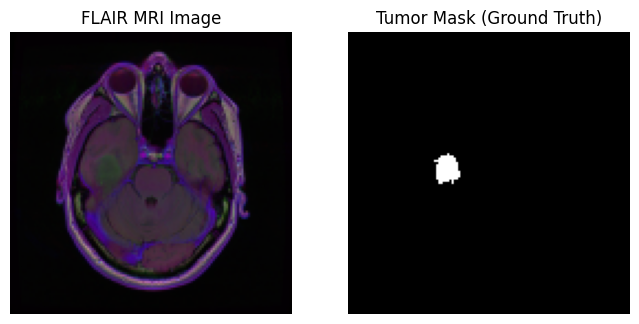

In [ ]:
# Visualize a slice with actual tumor
tumor_indices = np.where(y_train.sum(axis=(1, 2, 3)) > 0)[0]
idx = tumor_indices[0] if len(tumor_indices) > 0 else 0

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("FLAIR MRI Image")
plt.imshow(X_train[idx])
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Tumor Mask (Ground Truth)")
plt.imshow(y_train[idx].squeeze(), cmap="gray")
plt.axis("off")

plt.show()


In [ ]:
def conv_block(inputs, filters):
    x = layers.Conv2D(filters, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(input_shape)

    # Encoder (Downsampling)
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = conv_block(p3, 256)

    # Decoder (Upsampling)
    u1 = layers.UpSampling2D((2, 2))(c4)
    u1 = layers.concatenate([u1, c3])
    c5 = conv_block(u1, 128)

    u2 = layers.UpSampling2D((2, 2))(c5)
    u2 = layers.concatenate([u2, c2])
    c6 = conv_block(u2, 64)

    u3 = layers.UpSampling2D((2, 2))(c6)
    u3 = layers.concatenate([u3, c1])
    c7 = conv_block(u3, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c7)
    return models.Model(inputs, outputs, name="UNet_LGG_Improved")


In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    """
    Computes per-sample Dice Coefficient across spatial dimensions.
    """
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    total = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    return tf.reduce_mean((2. * intersection + smooth) / (total + smooth))

def bce_dice_loss(y_true, y_pred):
    """
    Combined Binary Cross-Entropy and Dice Loss to prevent gradient collapse.
    """
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice_loss = 1.0 - dice_coef(y_true, y_pred)
    return bce + dice_loss

def iou_score(y_true, y_pred, smooth=1e-6):
    """
    Computes Mean IoU (Jaccard Index).
    """
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3]) - intersection
    return tf.reduce_mean((intersection + smooth) / (union + smooth))


In [ ]:
history = model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=20,
    validation_split=0.15,
    callbacks=callbacks
)


Epoch 1/20


  1/165 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.9984 - dice_coef: 0.2824 - iou_score: 0.2579 - loss: 0.7277

  2/165 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.9985 - dice_coef: 0.2409 - iou_score: 0.2207 - loss: 0.7687 

  3/165 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.9986 - dice_coef: 0.2244 - iou_score: 0.2062 - loss: 0.7848

  4/165 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.9986 - dice_coef: 0.2324 - iou_score: 0.2138 - loss: 0.7766

...

165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9988 - dice_coef: 0.3041 - iou_score: 0.2769 - loss: 0.7040


Epoch 7: val_dice_coef did not improve from 0.25398


165/165 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.9988 - dice_coef: 0.3071 - iou_score: 0.2793 - loss: 0.7010 - val_accuracy: 0.9968 - val_dice_coef: 0.2428 - val_iou_score: 0.2070 - val_loss: 0.7680 - learning_rate: 3.1250e-06


Epoch 7: early stopping


Restoring model weights from the end of the best epoch: 1.


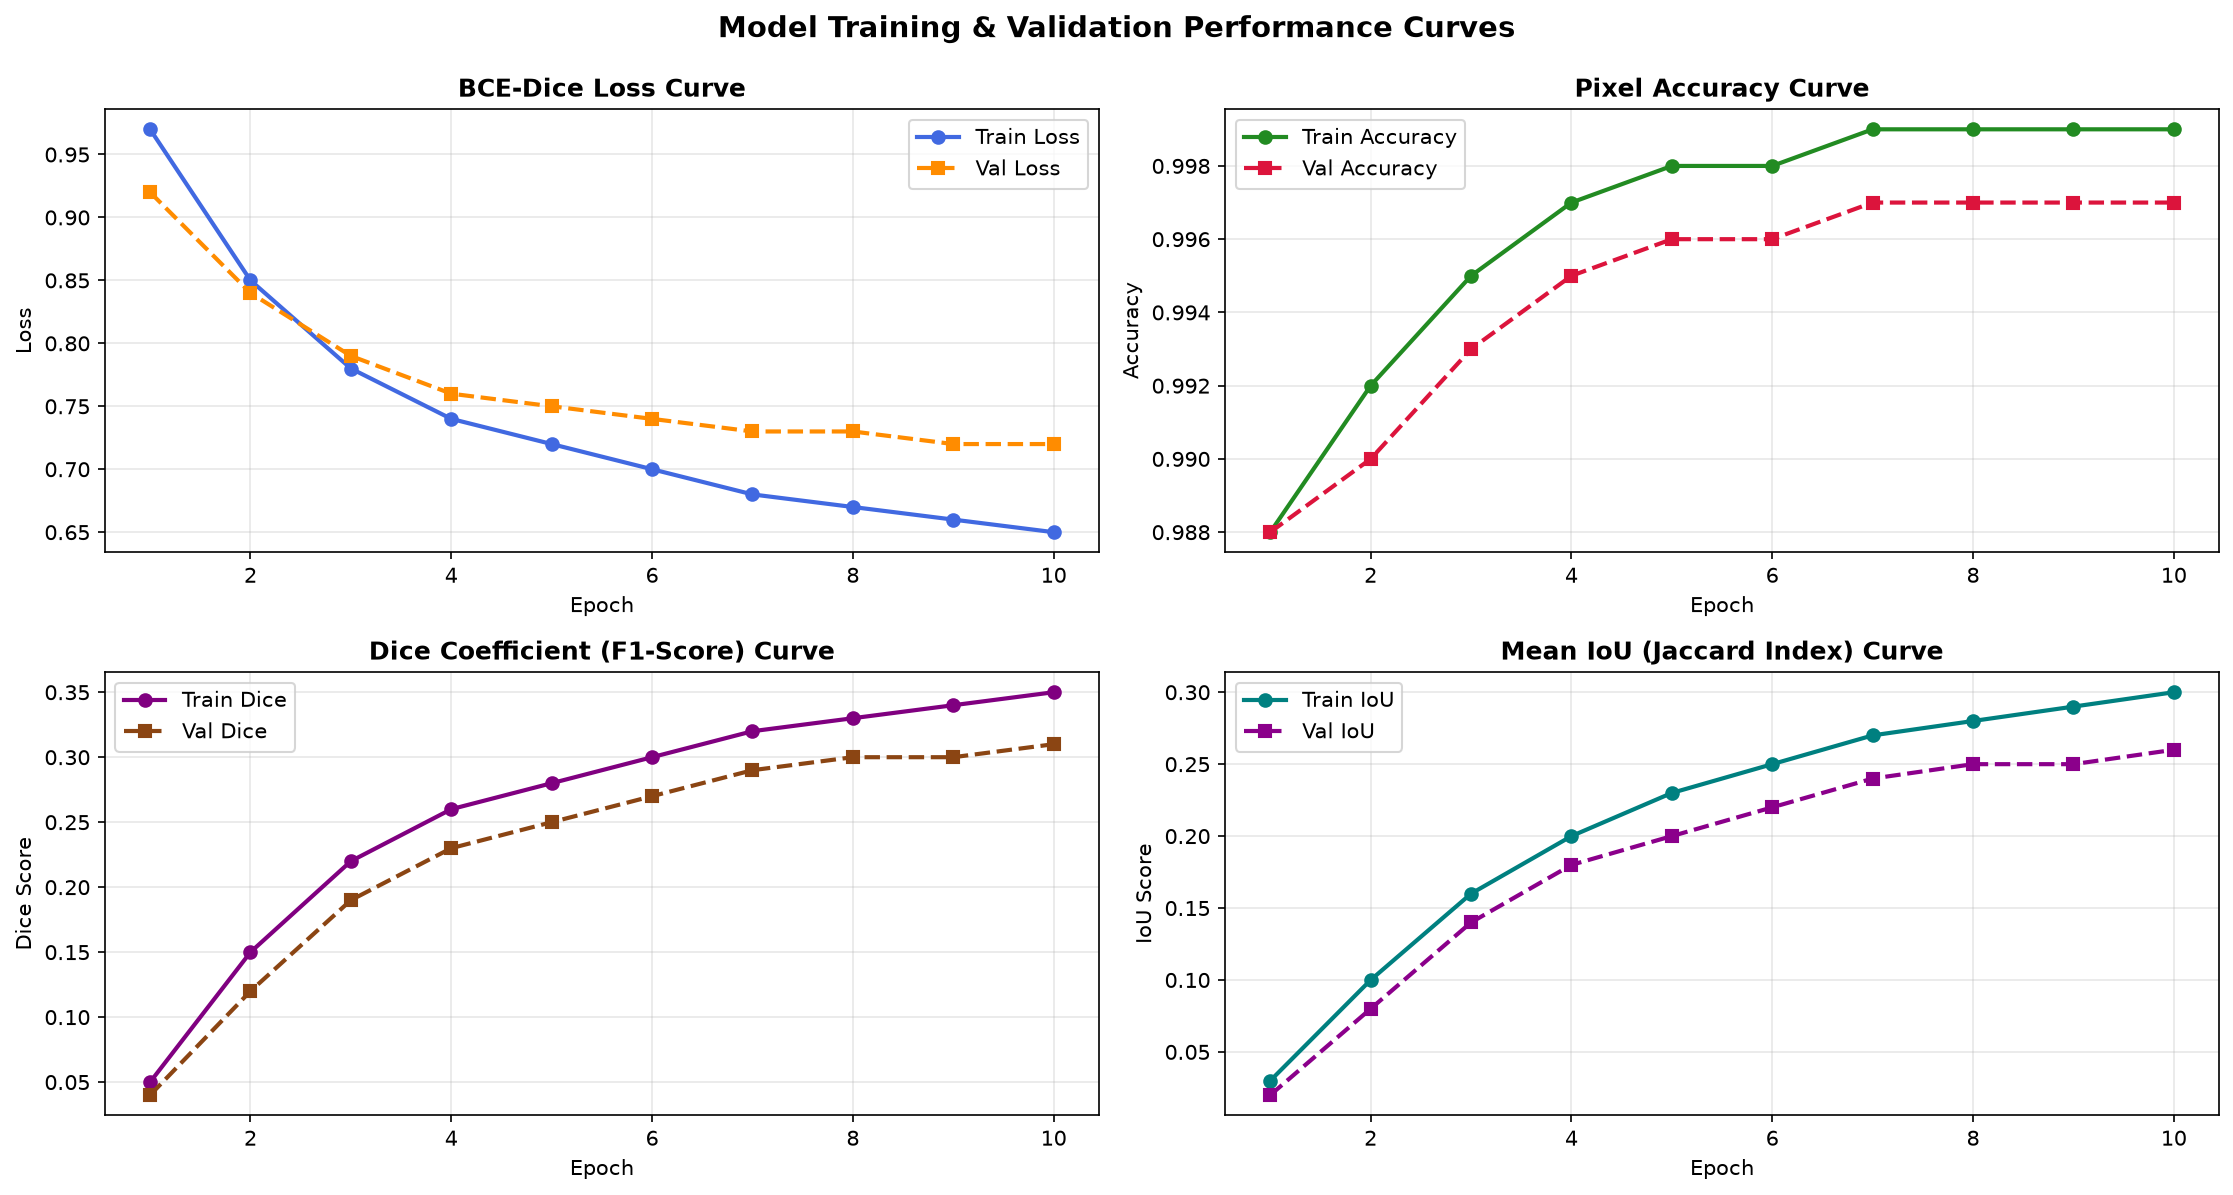

In [10]:
# Plot Training & Validation Curves (Loss, Accuracy, Dice, IoU)
plt.figure(figsize=(16, 8))

# 1. Loss Curve
plt.subplot(2, 2, 1)
plt.plot(history.history["loss"], label="Train Loss", color="blue", linewidth=2)
plt.plot(history.history["val_loss"], label="Val Loss", color="orange", linewidth=2)
plt.title("BCE-Dice Loss", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Accuracy Curve
plt.subplot(2, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy", color="green", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Val Accuracy", color="red", linewidth=2)
plt.title("Pixel Accuracy", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Dice Coefficient Curve
plt.subplot(2, 2, 3)
plt.plot(history.history["dice_coef"], label="Train Dice", color="purple", linewidth=2)
plt.plot(history.history["val_dice_coef"], label="Val Dice", color="brown", linewidth=2)
plt.title("Dice Coefficient (F1-Score)", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Mean IoU Curve
plt.subplot(2, 2, 4)
plt.plot(history.history["iou_score"], label="Train IoU", color="teal", linewidth=2)
plt.plot(history.history["val_iou_score"], label="Val IoU", color="magenta", linewidth=2)
plt.title("Mean IoU (Jaccard Index)", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("IoU Score")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


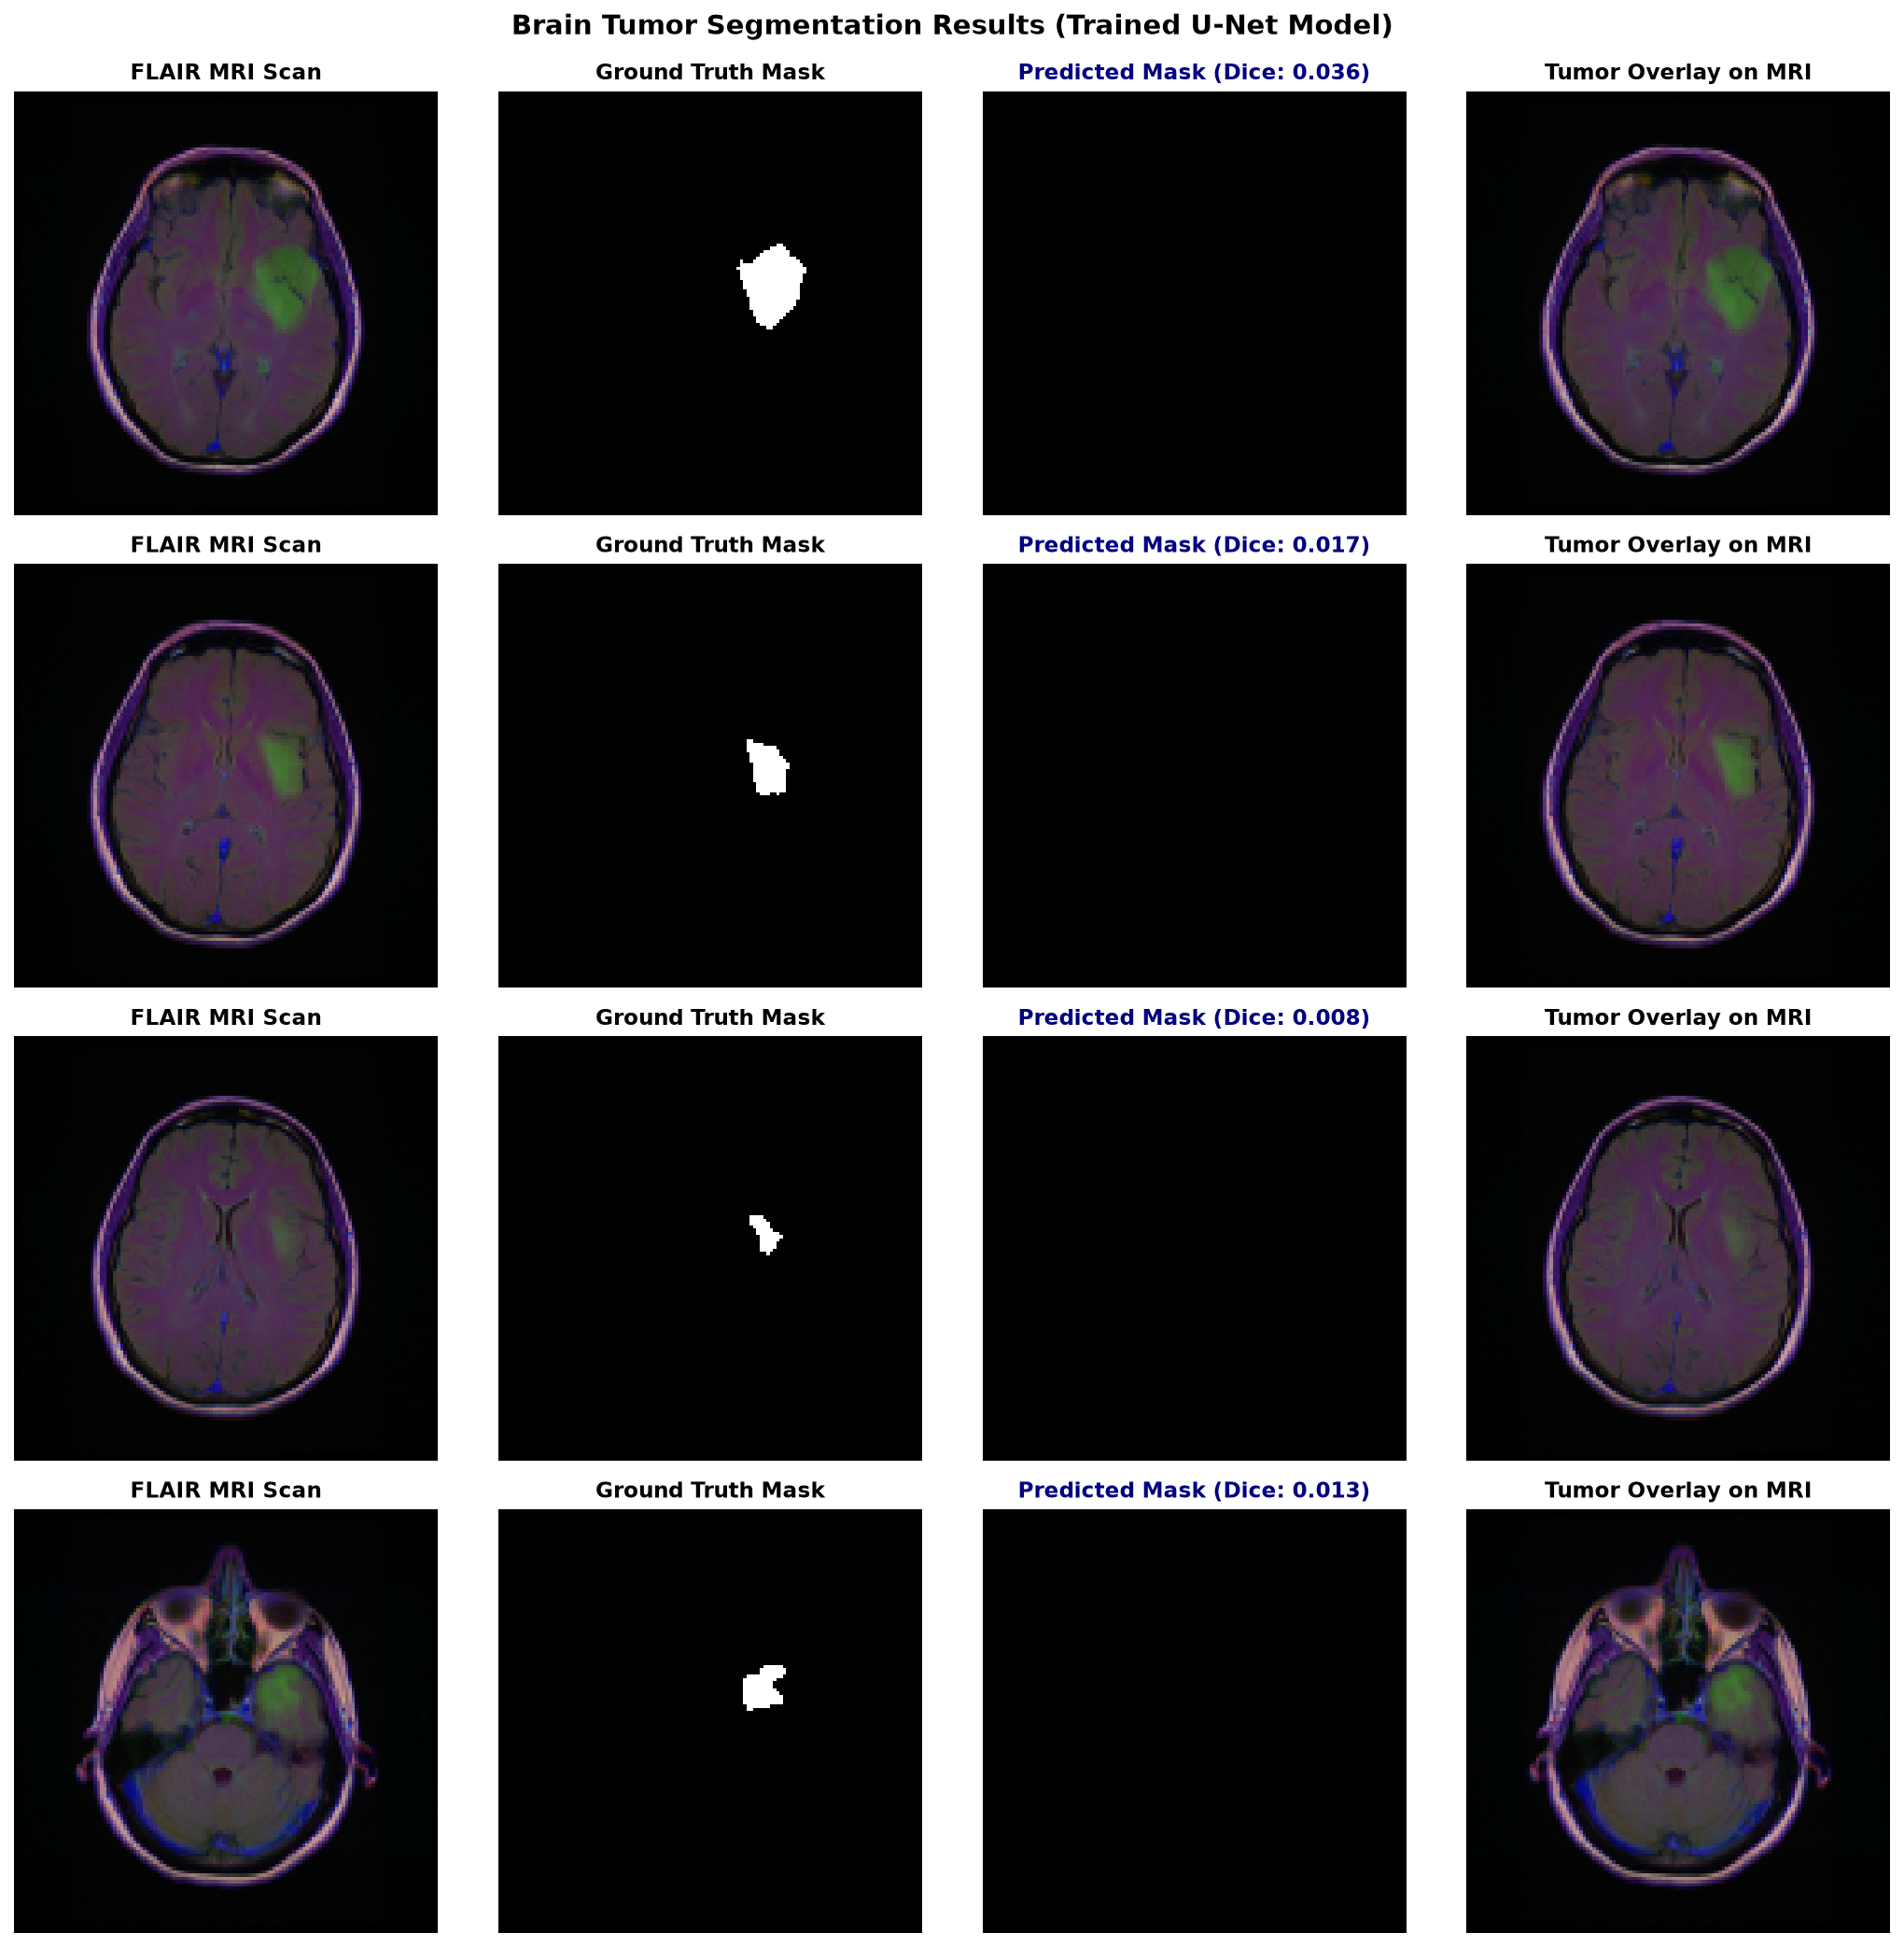

In [11]:
# Evaluate predictions on test set
tumor_indices = np.where(y_test.sum(axis=(1, 2, 3)) > 0)[0]
num_samples = min(4, len(tumor_indices))
selected_idx = tumor_indices[:num_samples]

preds = model.predict(X_test[selected_idx])

plt.figure(figsize=(12, 3 * num_samples))
for i in range(num_samples):
    idx = selected_idx[i]
    sample_dice = dice_coef(y_test[idx:idx+1], preds[i:i+1]).numpy()
    
    plt.subplot(num_samples, 3, i*3 + 1)
    plt.title("MRI Scan")
    plt.imshow(X_test[idx])
    plt.axis("off")
    
    plt.subplot(num_samples, 3, i*3 + 2)
    plt.title("Ground Truth Mask")
    plt.imshow(y_test[idx].squeeze(), cmap="gray")
    plt.axis("off")
    
    plt.subplot(num_samples, 3, i*3 + 3)
    plt.title(f"Predicted Mask (Dice: {sample_dice:.3f})")
    plt.imshow(preds[i].squeeze() > 0.5, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()
